# Assignment 05 - Fashion-MNIST: Benchmark CNN, VGG, ResNet và DenseNet

Notebook này tải Fashion-MNIST từ nguồn chính thức của Zalando Research, kiểm tra checksum bốn file IDX, split train/validation stratified và benchmark bốn kiến trúc CNN compact huấn luyện từ đầu.

## 1. Mục tiêu và quy trình

Dataset gồm 60.000 ảnh train và 10.000 ảnh test, mỗi ảnh grayscale `28x28`. Notebook tách `54.000/6.000` cho train/validation, chuẩn hóa theo train, augmentation chỉ hoạt động trong training và đánh giá test bằng Accuracy, Macro Precision/Recall/F1, loss, số tham số và thời gian.

## 2. Cấu hình thư viện và seed

Cell này cố định seed, thiết lập thư viện và các tham số huấn luyện chung cho toàn bộ benchmark.

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"

from pathlib import Path
import gzip
import hashlib
import random
import struct
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic ops: enabled")
except Exception as exc:
    print("TensorFlow deterministic ops unavailable:", exc)

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.4f}".format
print("TensorFlow:", tf.__version__)

TensorFlow deterministic ops: enabled
TensorFlow: 2.21.0


## 3. CNN như hàm hợp

Với ảnh, CNN là một chuỗi hàm hợp:

`x -> Convolution -> BatchNorm -> ReLU -> Pooling -> Classifier -> Probability`.

Convolution trích đặc trưng cục bộ, BatchNorm ổn định phân phối kích hoạt, ReLU thêm phi tuyến, pooling giảm kích thước không gian, classifier đổi feature map thành xác suất lớp.

In [2]:
def conv2d_valid(image, kernel):
    image = np.asarray(image, dtype="float32")
    kernel = np.asarray(kernel, dtype="float32")
    kh, kw = kernel.shape
    out = np.zeros((image.shape[0] - kh + 1, image.shape[1] - kw + 1), dtype="float32")
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(image[i : i + kh, j : j + kw] * kernel)
    return out


def max_pool2d_valid(image, pool_size=2):
    h = (image.shape[0] // pool_size) * pool_size
    w = (image.shape[1] // pool_size) * pool_size
    clipped = image[:h, :w]
    return clipped.reshape(h // pool_size, pool_size, w // pool_size, pool_size).max(axis=(1, 3))


def softmax(logits):
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


x_demo = np.arange(36, dtype="float32").reshape(6, 6) / 35.0
kernel_demo = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype="float32")
conv_demo = conv2d_valid(x_demo, kernel_demo)
bn_demo = (conv_demo - conv_demo.mean()) / (conv_demo.std() + 1e-6)
relu_demo = np.maximum(bn_demo, 0)
pool_demo = max_pool2d_valid(relu_demo, pool_size=2)
flat_demo = pool_demo.reshape(1, -1)
logits_demo = flat_demo @ np.linspace(-0.2, 0.2, flat_demo.shape[1] * 3).reshape(flat_demo.shape[1], 3)
prob_demo = softmax(logits_demo)

shape_flow = pd.DataFrame(
    [
        ("Input x", x_demo.shape),
        ("Convolution", conv_demo.shape),
        ("BatchNorm", bn_demo.shape),
        ("ReLU", relu_demo.shape),
        ("Pooling", pool_demo.shape),
        ("Flatten", flat_demo.shape),
        ("Softmax probability", prob_demo.shape),
    ],
    columns=["Bước", "Shape"],
)
display(shape_flow)
print("Tổng xác suất:", prob_demo.sum(axis=1))

,Bước,Shape
0,Input x,"(6, 6)"
1,Convolution,"(4, 4)"
2,BatchNorm,"(4, 4)"
3,ReLU,"(4, 4)"
4,Pooling,"(2, 2)"
5,Flatten,"(1, 4)"
6,Softmax probability,"(1, 3)"


Tổng xác suất: [1.]


## 3. Ba hướng phát triển từ CNN

Các kiến trúc dưới đây đều có thể nhìn như những cách khác nhau để thiết kế hàm hợp:

- **VGG**: tăng độ sâu bằng cách chồng nhiều convolution `3x3`: `H(x)=Conv3x3(ReLU(BN(Conv3x3(x))))`.
- **ResNet**: học phần dư thay vì học toàn bộ ánh xạ: `y = ReLU(F(x) + P(x))`, trong đó `P(x)` là phép chiếu `1x1` khi cần đổi số kênh hoặc stride.
- **DenseNet**: mỗi lớp nhận tất cả đặc trưng trước đó: `x_l = H_l([x_0, x_1, ..., x_{l-1}])`.

Trong notebook này, các phiên bản đều là compact và huấn luyện từ đầu, không dùng pretrained.

## 4. Hiện thực kiến trúc Conv2D

Bốn builder dưới đây chia sẻ cùng preprocessing input. Augmentation nằm trong model nên chỉ áp dụng khi training; validation/test chỉ resize/rescale/standardize.

In [3]:
def make_image_preprocessor(mean, std, image_size=None, augment=False, contrast=0.0, name="input_preprocess"):
    preprocess_layers = []
    if image_size is not None:
        preprocess_layers.append(layers.Resizing(image_size, image_size, interpolation="bilinear", name="resize"))
    preprocess_layers.append(layers.Rescaling(1.0 / 255.0, name="rescale_01"))
    if augment:
        preprocess_layers.extend(
            [
                layers.RandomFlip("horizontal", seed=SEED, name="aug_flip"),
                layers.RandomTranslation(0.08, 0.08, fill_mode="nearest", seed=SEED + 1, name="aug_shift"),
                layers.RandomRotation(0.05, fill_mode="nearest", seed=SEED + 2, name="aug_rotate"),
                layers.RandomZoom(0.08, fill_mode="nearest", seed=SEED + 3, name="aug_zoom"),
            ]
        )
        if contrast > 0:
            preprocess_layers.append(layers.RandomContrast(contrast, seed=SEED + 4, name="aug_contrast"))
    mean_tensor = tf.constant(np.asarray(mean, dtype="float32").reshape((1, 1, 1, -1)))
    std_tensor = tf.constant(np.asarray(std, dtype="float32").reshape((1, 1, 1, -1)))
    preprocess_layers.append(layers.Lambda(lambda z: (z - mean_tensor) / std_tensor, name="train_standardization"))
    return tf.keras.Sequential(preprocess_layers, name=name)


def conv2d_bn_relu(x, filters, kernel_size=3, strides=1, name="conv"):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def build_basic_cnn(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    for stage, filters in enumerate([32, 64, 128], start=1):
        x = conv2d_bn_relu(x, filters, name=f"basic_s{stage}")
        x = layers.MaxPooling2D(pool_size=2, name=f"basic_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"basic_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="basic_cnn")


def build_vgg_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    for stage, (num_convs, filters) in enumerate(zip([2, 2, 3], [32, 64, 128]), start=1):
        for block in range(1, num_convs + 1):
            x = conv2d_bn_relu(x, filters, name=f"vgg_s{stage}_b{block}")
        x = layers.MaxPooling2D(pool_size=2, name=f"vgg_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"vgg_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.40, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_vgg")


def residual_block_2d(x, filters, stride=1, name="res"):
    shortcut = x
    x = layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"{name}_proj_conv",
        )(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    return layers.Activation("relu", name=f"{name}_out")(x)


def build_resnet_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    x = conv2d_bn_relu(x, 32, name="stem")
    for stage, filters in enumerate([32, 64, 128], start=1):
        stride = 1 if stage == 1 else 2
        x = residual_block_2d(x, filters, stride=stride, name=f"res_s{stage}_b1")
        x = residual_block_2d(x, filters, stride=1, name=f"res_s{stage}_b2")
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_resnet")


def dense_layer_2d(x, growth_rate=16, name="dense_layer"):
    y = layers.BatchNormalization(name=f"{name}_bn1")(x)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Conv2D(
        growth_rate * 4,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = layers.Activation("relu", name=f"{name}_relu2")(y)
    y = layers.Conv2D(
        growth_rate,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(y)
    return layers.Concatenate(axis=-1, name=f"{name}_concat")([x, y])


def dense_block_2d(x, num_layers, growth_rate=16, name="dense_block"):
    for layer_idx in range(1, num_layers + 1):
        x = dense_layer_2d(x, growth_rate=growth_rate, name=f"{name}_l{layer_idx}")
    return x


def transition_block_2d(x, compression=0.5, name="transition"):
    filters = max(8, int(int(x.shape[-1]) * compression))
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    x = layers.Conv2D(
        filters,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    return layers.AveragePooling2D(pool_size=2, name=f"{name}_pool")(x)


def build_densenet_compact(input_shape, num_classes, mean, std, image_size=None, augment=True, contrast=0.0):
    inputs = layers.Input(shape=input_shape)
    x = make_image_preprocessor(mean, std, image_size=image_size, augment=augment, contrast=contrast)(inputs)
    x = conv2d_bn_relu(x, 32, name="stem")
    for block_idx, num_layers in enumerate([3, 4, 4], start=1):
        x = dense_block_2d(x, num_layers, growth_rate=16, name=f"dense_b{block_idx}")
        if block_idx < 3:
            x = transition_block_2d(x, compression=0.5, name=f"trans_b{block_idx}")
    x = layers.BatchNormalization(name="final_bn")(x)
    x = layers.Activation("relu", name="final_relu")(x)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dropout(0.35, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="class_probability")(x)
    return models.Model(inputs, outputs, name="compact_densenet")


MODEL_BUILDERS = [
    ("Basic CNN", build_basic_cnn),
    ("Compact VGG", build_vgg_compact),
    ("Compact ResNet", build_resnet_compact),
    ("Compact DenseNet", build_densenet_compact),
]

## 5. Tải Fashion-MNIST và kiểm tra checksum

Notebook tải bốn file IDX gzip từ repository chính thức `zalandoresearch/fashion-mnist`, lưu vào thư mục `data` và xác nhận MD5 trước khi đọc.

In [4]:
def resolve_data_dir():
    candidates = [
        Path.cwd().parent / "data",
        Path.cwd() / "data",
        Path("src/Assignment 05/Fashion-MNIST/data"),
    ]
    for candidate in candidates:
        if candidate.exists() or "src/Assignment 05" in str(candidate):
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục data cho Fashion-MNIST.")


DATA_DIR = resolve_data_dir()
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion"
FASHION_FILES = {
    "train-images-idx3-ubyte.gz": ("8d4fb7e6c68d591d4c3dfef9ec88bf0d", f"{BASE_URL}/train-images-idx3-ubyte.gz"),
    "train-labels-idx1-ubyte.gz": ("25c81989df183df01b3e8a0aad5dffbe", f"{BASE_URL}/train-labels-idx1-ubyte.gz"),
    "t10k-images-idx3-ubyte.gz": ("bef4ecab320f06d8554ea6380940ec79", f"{BASE_URL}/t10k-images-idx3-ubyte.gz"),
    "t10k-labels-idx1-ubyte.gz": ("bb300cfdad3c16e7a12a480ee83cd310", f"{BASE_URL}/t10k-labels-idx1-ubyte.gz"),
}


def md5_file(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_with_md5(filename, expected_md5, url):
    path = DATA_DIR / filename
    if path.exists() and md5_file(path) == expected_md5:
        print(f"OK checksum: {filename}")
        return path
    tmp_path = path.with_suffix(path.suffix + ".part")
    print(f"Downloading {filename} ...")
    urllib.request.urlretrieve(url, tmp_path)
    actual_md5 = md5_file(tmp_path)
    if actual_md5 != expected_md5:
        tmp_path.unlink(missing_ok=True)
        raise ValueError(f"MD5 mismatch for {filename}: {actual_md5} != {expected_md5}")
    tmp_path.replace(path)
    print(f"Saved {path}")
    return path


paths = {
    filename: download_with_md5(filename, expected_md5, url)
    for filename, (expected_md5, url) in FASHION_FILES.items()
}

Saved /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/Fashion-MNIST/data/train-images-idx3-ubyte.gz


Saved /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/Fashion-MNIST/data/train-labels-idx1-ubyte.gz


Saved /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/Fashion-MNIST/data/t10k-images-idx3-ubyte.gz


Saved /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/Fashion-MNIST/data/t10k-labels-idx1-ubyte.gz


## 6. Đọc IDX, split stratified và EDA

Tập train gốc được tách thành 54.000 train và 6.000 validation bằng stratified split. Tập test 10.000 ảnh giữ nguyên và không tham gia preprocessing fit, early stopping hay chọn mô hình.

Split: (54000, 28, 28, 1) (6000, 28, 28, 1) (10000, 28, 28, 1)
Mean/std train: [0.28620902] [0.35316077]


,class,train,validation,test
0,T-shirt/top,5400,600,1000
1,Trouser,5400,600,1000
2,Pullover,5400,600,1000
3,Dress,5400,600,1000
4,Coat,5400,600,1000
5,Sandal,5400,600,1000
6,Shirt,5400,600,1000
7,Sneaker,5400,600,1000
8,Bag,5400,600,1000
9,Ankle boot,5400,600,1000


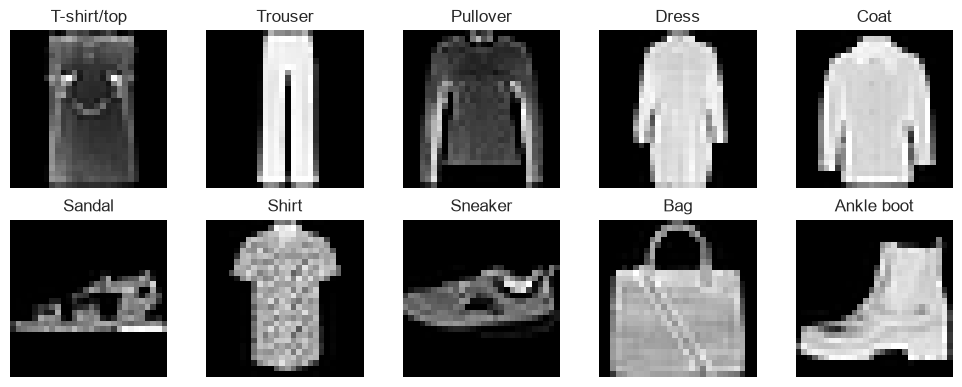

In [5]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
NUM_CLASSES = len(CLASS_NAMES)


def read_idx_images(path):
    with gzip.open(path, "rb") as file:
        magic, count, rows, cols = struct.unpack(">IIII", file.read(16))
        assert magic == 2051
        data = np.frombuffer(file.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols, 1)


def read_idx_labels(path):
    with gzip.open(path, "rb") as file:
        magic, count = struct.unpack(">II", file.read(8))
        assert magic == 2049
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    assert len(labels) == count
    return labels.astype("int32")


x_train_full = read_idx_images(paths["train-images-idx3-ubyte.gz"])
y_train_full = read_idx_labels(paths["train-labels-idx1-ubyte.gz"])
x_test = read_idx_images(paths["t10k-images-idx3-ubyte.gz"])
y_test = read_idx_labels(paths["t10k-labels-idx1-ubyte.gz"])

assert x_train_full.shape == (60000, 28, 28, 1)
assert x_test.shape == (10000, 28, 28, 1)
assert set(np.unique(y_train_full)) == set(range(NUM_CLASSES))
assert set(np.unique(y_test)) == set(range(NUM_CLASSES))

full_idx = np.arange(len(x_train_full))
train_idx, val_idx = train_test_split(
    full_idx,
    test_size=6000,
    random_state=SEED,
    stratify=y_train_full,
)
assert set(train_idx).isdisjoint(val_idx)
x_train = x_train_full[train_idx]
y_train = y_train_full[train_idx]
x_val = x_train_full[val_idx]
y_val = y_train_full[val_idx]
assert x_train.shape[0] == 54000 and x_val.shape[0] == 6000

INPUT_SHAPE = x_train.shape[1:]
RESIZE_TO = None
AUG_CONTRAST = 0.0
MAX_EPOCHS = 25
TRAIN_BATCH_SIZE = 128
EARLY_STOPPING_PATIENCE = 5

train_float = x_train.astype("float32") / 255.0
IMAGE_MEAN = train_float.mean(axis=(0, 1, 2))
IMAGE_STD = train_float.std(axis=(0, 1, 2)) + 1e-6
print("Split:", x_train.shape, x_val.shape, x_test.shape)
print("Mean/std train:", IMAGE_MEAN, IMAGE_STD)

display(
    pd.DataFrame(
        {
            "class": CLASS_NAMES,
            "train": np.bincount(y_train, minlength=NUM_CLASSES),
            "validation": np.bincount(y_val, minlength=NUM_CLASSES),
            "test": np.bincount(y_test, minlength=NUM_CLASSES),
        }
    )
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for class_id, ax in enumerate(axes.ravel()):
    sample_idx = np.flatnonzero(y_train == class_id)[0]
    ax.imshow(x_train[sample_idx].squeeze(), cmap="gray")
    ax.set_title(CLASS_NAMES[class_id])
    ax.axis("off")
plt.tight_layout()
plt.show()

del x_train_full, y_train_full, train_float

## 7. Huấn luyện và đánh giá bốn mô hình

Tất cả mô hình dùng cùng split, loss, optimizer AdamW, augmentation, `ReduceLROnPlateau` và early stopping theo `val_loss`.

In [6]:
EPOCHS = MAX_EPOCHS
BATCH_SIZE = TRAIN_BATCH_SIZE
histories = {}
results = []
test_probabilities = {}
test_predictions = {}
confusion_matrices = {}

for model_name, builder in MODEL_BUILDERS:
    print(f"\n===== {model_name} =====")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = builder(
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        mean=IMAGE_MEAN,
        std=IMAGE_STD,
        image_size=RESIZE_TO,
        augment=True,
        contrast=AUG_CONTRAST,
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1
        ),
    ]
    start = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    test_loss, test_acc = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=0)
    infer_start = time.perf_counter()
    y_prob = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    inference_time = time.perf_counter() - infer_start
    assert y_prob.shape == (len(y_test), NUM_CLASSES)
    assert np.all(np.isfinite(y_prob))
    assert np.allclose(y_prob.sum(axis=1), 1.0, atol=1e-4)
    y_pred = y_prob.argmax(axis=1)
    assert set(np.unique(y_pred)).issubset(set(range(NUM_CLASSES)))
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))
    assert cm.shape == (NUM_CLASSES, NUM_CLASSES)
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    results.append(
        {
            "Model": model_name,
            "Accuracy": float(test_acc),
            "Macro Precision": float(precision),
            "Macro Recall": float(recall),
            "Macro F1": float(f1),
            "Test Loss": float(test_loss),
            "Params": int(model.count_params()),
            "Best Epoch": best_epoch,
            "Train Time (s)": float(train_time),
            "Inference Time (s)": float(inference_time),
        }
    )
    histories[model_name] = history.history
    test_probabilities[model_name] = y_prob
    test_predictions[model_name] = y_pred
    confusion_matrices[model_name] = cm
    print(f"{model_name}: params={model.count_params():,}, best_epoch={best_epoch}, test_acc={test_acc:.4f}, macro_f1={f1:.4f}")
    del model

results_df = pd.DataFrame(results).set_index("Model")
assert len(results_df) == 4
assert not results_df.isna().any().any()
display(results_df.sort_values("Macro F1", ascending=False))


===== Basic CNN =====


Epoch 1/25


E0000 00:00:1790267090.174556 3718788 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


E0000 00:00:1790267105.311048 3718788 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


422/422 - 16s - 37ms/step - accuracy: 0.6375 - loss: 0.9767 - val_accuracy: 0.7458 - val_loss: 0.6532 - learning_rate: 0.0010


...

422/422 - 121s - 287ms/step - accuracy: 0.9168 - loss: 0.2328 - val_accuracy: 0.9122 - val_loss: 0.2361 - learning_rate: 6.2500e-05


Restoring model weights from the end of the best epoch: 25.


E0000 00:00:1790274105.006007 3718788 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Compact DenseNet: params=163,458, best_epoch=25, test_acc=0.9032, macro_f1=0.9030


,Accuracy,Macro Precision,Macro Recall,Macro F1,Test Loss,Params,Best Epoch,Train Time (s),Inference Time (s)
Model,,,,,,,,,
Compact ResNet,0.9204,0.9201,0.9204,0.9199,0.2203,698282,23,2114.6595,3.9201
Compact VGG,0.9173,0.9190,0.9173,0.9178,0.2204,453546,23,1047.4144,1.9212
Compact DenseNet,0.9032,0.9031,0.9032,0.9030,0.2571,163458,25,3043.9511,4.5640
Basic CNN,0.8743,0.8766,0.8743,0.8746,0.3453,111146,23,368.8322,0.6690


## 8. Learning curves và biểu đồ metric

Loss/accuracy train-validation cho biết mô hình có học ổn định không; biểu đồ metric test dùng để so sánh trực tiếp bốn kiến trúc.

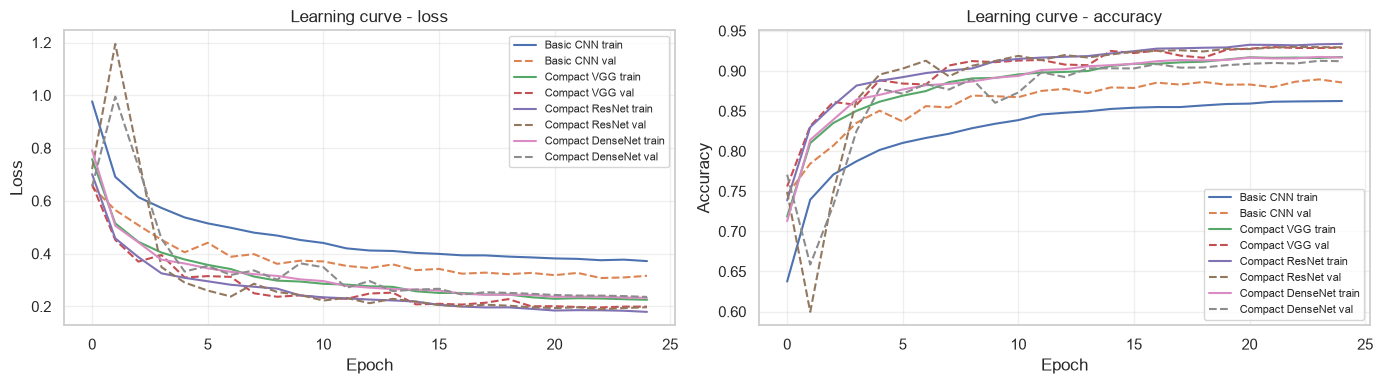

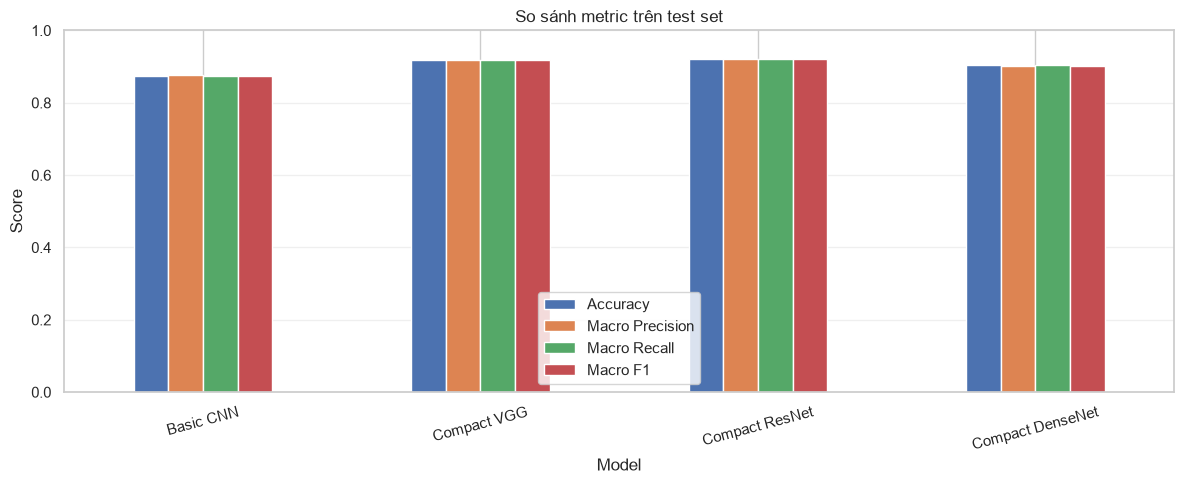

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for model_name, hist in histories.items():
    axes[0].plot(hist["loss"], label=f"{model_name} train")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"{model_name} val")
    axes[1].plot(hist["accuracy"], label=f"{model_name} train")
    axes[1].plot(hist["val_accuracy"], linestyle="--", label=f"{model_name} val")
axes[0].set_title("Learning curve - loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Learning curve - accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ax = results_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].plot(
    kind="bar", figsize=(12, 5), ylim=(0, 1), rot=15
)
ax.set_title("So sánh metric trên test set")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Confusion matrix chuẩn hóa

Fashion-MNIST có 10 lớp nên mỗi ma trận nhầm lẫn phải có kích thước `10x10`.

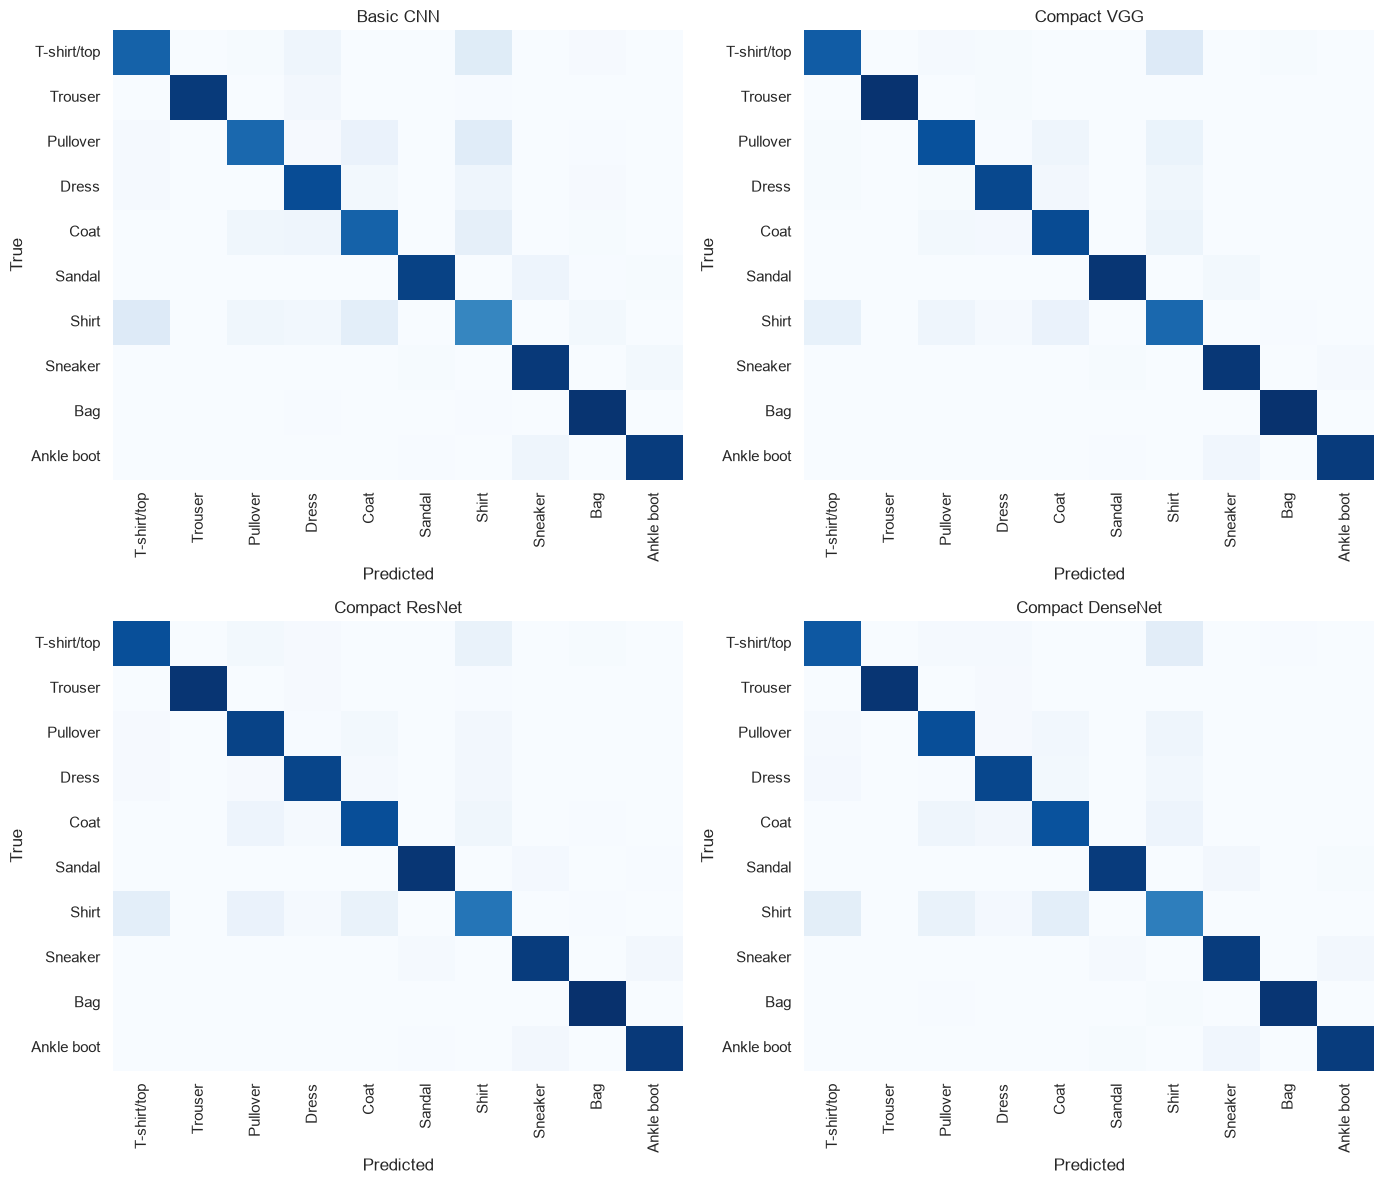

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (model_name, cm) in zip(axes.ravel(), confusion_matrices.items()):
    cm_norm = cm.astype("float32") / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    assert cm_norm.shape == (NUM_CLASSES, NUM_CLASSES)
    sns.heatmap(
        cm_norm,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=False,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 10. Phân tích lỗi và kết luận tự sinh

Cell dưới hiển thị một số ảnh dự đoán sai của mô hình có Macro F1 tốt nhất và tự rút kết luận từ bảng benchmark.

Mô hình tốt nhất theo Macro F1: Compact ResNet
Số ảnh dự đoán sai trên test set: 796 / 10000


,index,true,pred,confidence
0,17,Coat,Shirt,0.5902
1,23,Ankle boot,Sandal,0.9791
2,32,Dress,Bag,0.7597
3,42,Dress,Shirt,0.5037
4,43,Sneaker,Ankle boot,0.7408
5,68,Ankle boot,Sneaker,0.9751
6,89,Shirt,Pullover,0.8617
7,98,Coat,Pullover,0.9311
8,103,Pullover,Shirt,0.5670
9,107,Ankle boot,Sneaker,0.6293


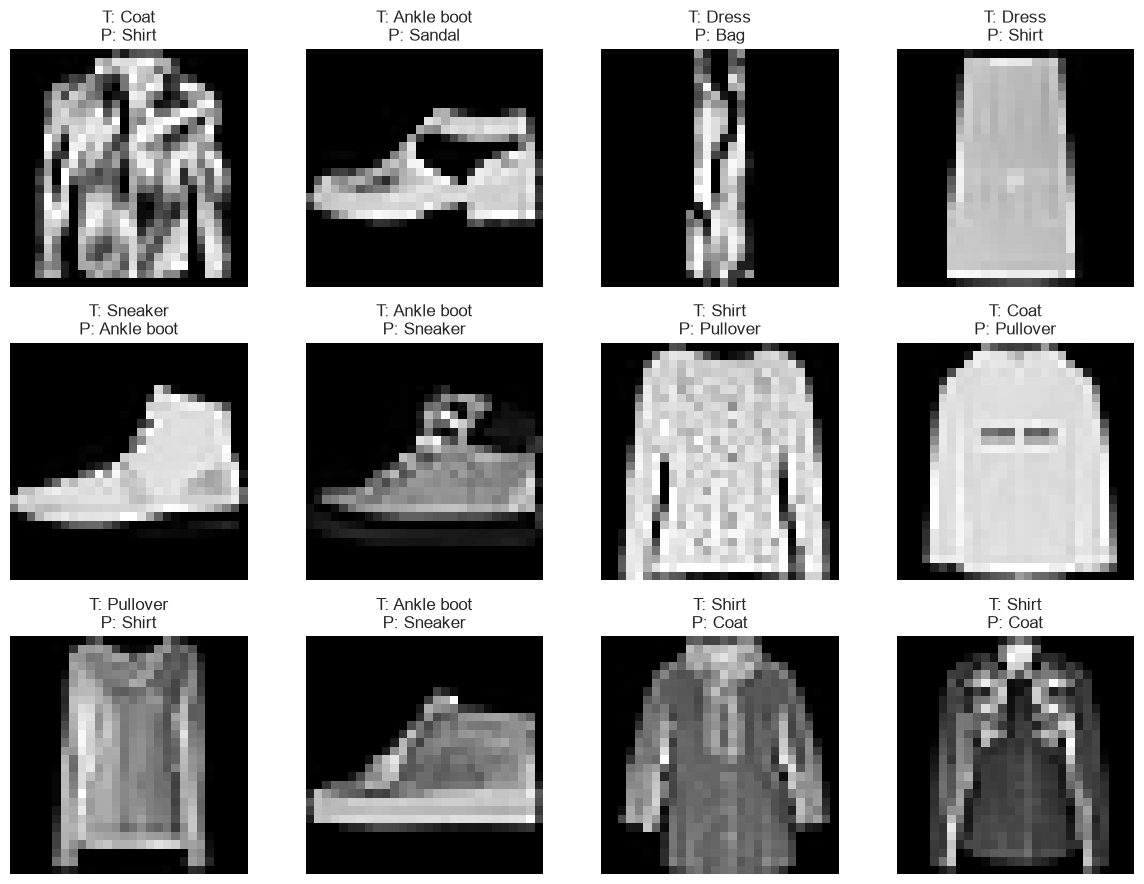

Kết luận: Compact ResNet đạt Macro F1 cao nhất (0.9199), trong khi Compact ResNet có accuracy cao nhất (0.9204). Basic CNN có thời gian inference thấp nhất trong lần chạy này. Vì Fashion-MNIST cân bằng giữa các lớp, accuracy và Macro F1 thường gần nhau; những nhầm lẫn phổ biến thường nằm giữa các lớp quần áo có hình dạng gần giống như shirt, pullover và coat.


In [9]:
best_model_name = results_df["Macro F1"].idxmax()
best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]
wrong_idx = np.flatnonzero(best_pred != y_test)
print(f"Mô hình tốt nhất theo Macro F1: {best_model_name}")
print(f"Số ảnh dự đoán sai trên test set: {len(wrong_idx)} / {len(y_test)}")

error_rows = []
for idx in wrong_idx[:20]:
    error_rows.append(
        {
            "index": int(idx),
            "true": CLASS_NAMES[int(y_test[idx])],
            "pred": CLASS_NAMES[int(best_pred[idx])],
            "confidence": float(best_prob[idx, best_pred[idx]]),
        }
    )
display(pd.DataFrame(error_rows).head(12))

if len(wrong_idx) > 0:
    sample_idx = wrong_idx[:12]
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    for ax, idx in zip(axes.ravel(), sample_idx):
        image = x_test[idx]
        if image.shape[-1] == 1:
            ax.imshow(image.squeeze(), cmap="gray")
        else:
            ax.imshow(image)
        ax.set_title(
            f"T: {CLASS_NAMES[int(y_test[idx])]}\nP: {CLASS_NAMES[int(best_pred[idx])]}"
        )
        ax.axis("off")
    for ax in axes.ravel()[len(sample_idx):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


best_acc = results_df["Accuracy"].idxmax()
best_f1 = results_df["Macro F1"].idxmax()
fastest = results_df["Inference Time (s)"].idxmin()
print(
    f"Kết luận: {best_f1} đạt Macro F1 cao nhất ({results_df.loc[best_f1, 'Macro F1']:.4f}), "
    f"trong khi {best_acc} có accuracy cao nhất ({results_df.loc[best_acc, 'Accuracy']:.4f}). "
    f"{fastest} có thời gian inference thấp nhất trong lần chạy này. "
    "Vì Fashion-MNIST cân bằng giữa các lớp, accuracy và Macro F1 thường gần nhau; "
    "những nhầm lẫn phổ biến thường nằm giữa các lớp quần áo có hình dạng gần giống như shirt, pullover và coat."
)